In [ ]:
import torch
import torch.nn as nn

class AIPilotPolicy(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        # Perception / feature extractor
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU()
        )
        # Policy head
        self.policy_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
        # Value head
        self.value_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, obs):
        features = self.encoder(obs)
        logits = self.policy_head(features)
        value = self.value_head(features)
        return logits, value


In [ ]:
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]  # or n for discrete
model = AIPilotPolicy(obs_dim, action_dim).to(device)


In [ ]:
# Placeholder for AIPilotEnv. Replace with your actual environment.
class AIPilotEnv:
    def __init__(self, *args, **kwargs):
        # Dummy spaces for demonstration
        class Space:
            def __init__(self, shape):
                self.shape = shape
        self.observation_space = Space(shape=(4,))
        self.action_space = Space(shape=(2,))

env = AIPilotEnv() # Remove the '...' placeholder and instantiate the environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]  # or n for discrete
model = AIPilotPolicy(obs_dim, action_dim).to(device)

In [ ]:
# Training hyperparameters
num_updates = 1000
rollout_length = 2048
log_interval = 10

# Placeholder for optimizer (e.g., Adam)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# You'll need to define collect_rollout and ppo_update functions

log_history = []


In [ ]:
import torch.optim as optim

# Placeholder for collect_rollout function
def collect_rollout(env, model, rollout_length):
    # This is a dummy implementation. Replace with actual rollout collection logic.
    # It should return a dictionary or object containing collected experiences.
    print("Collecting dummy rollout...")
    # Example of a dummy return, assuming 'rollouts' will contain 'obs', 'actions', 'rewards', etc.
    # For now, return a placeholder that won't immediately break ppo_update's expected input.
    return {"observations": [], "actions": [], "rewards": [], "log_probs": [], "values": [], "advantages": []}

# Placeholder for ppo_update function
def ppo_update(model, optimizer, rollouts):
    # This is a dummy implementation. Replace with actual PPO update logic.
    print("Performing dummy PPO update...")
    # Return a dictionary with dummy loss values and reward
    return {"mean_reward": 0.0, "policy_loss": 0.0, "value_loss": 0.0, "entropy": 0.0}

# Placeholder for optimizer (model needs to be defined first)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for update in range(num_updates):
    rollouts = collect_rollout(env, model, rollout_length)
    loss_dict = ppo_update(model, optimizer, rollouts)

    if update % log_interval == 0:
        print(f"Update {update}: "
              f"reward={loss_dict['mean_reward']:.2f}, "
              f"policy_loss={loss_dict['policy_loss']:.4f}, "
              f"value_loss={loss_dict['value_loss']:.4f}, "
              f"entropy={loss_dict['entropy']:.4f}")
        log_history.append(loss_dict)


Performing dummy PPO update...
Update 0: reward=0.00, policy_loss=0.0000, value_loss=0.0000, entropy=0.0000
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Update 10: reward=0.00, policy_loss=0.0000, value_loss=0.0000, entropy=0.0000
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Update 20: reward=0.00, policy_loss=0.0000, value_loss=0.0000, entropy=0.0000
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO update...
Performing dummy PPO up

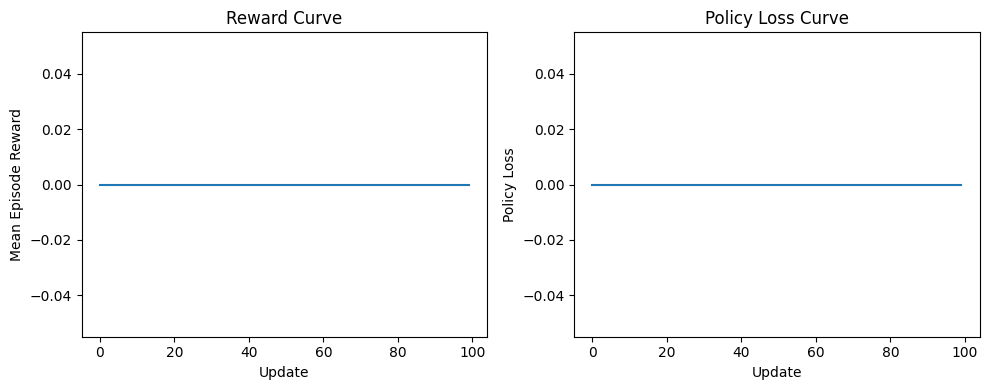

In [ ]:
import matplotlib.pyplot as plt

updates = range(len(log_history))
mean_rewards = [d['mean_reward'] for d in log_history]
policy_losses = [d['policy_loss'] for d in log_history]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(updates, mean_rewards)
plt.xlabel("Update")
plt.ylabel("Mean Episode Reward")
plt.title("Reward Curve")

plt.subplot(1, 2, 2)
plt.plot(updates, policy_losses)
plt.xlabel("Update")
plt.ylabel("Policy Loss")
plt.title("Policy Loss Curve")

plt.tight_layout()
plt.show()
